# UMAP Visualization of scGPT Fine-tuned Cell Embeddings

Author: Tengxiao Gao

Description:
This script loads cell embeddings generated by a fine-tuned scGPT model
and performs neighborhood graph construction and UMAP visualization.

The scGPT embedding is automatically selected from `adata.obsm`,
then used to compute a kNN graph (cosine distance) and generate a UMAP
representation for visualization.

Main steps:
- Load AnnData file with scGPT embeddings
- Automatically identify the embedding key in `adata.obsm`
- Compute neighborhood graph using the embedding
- Run UMAP for dimensionality reduction
- Visualize cells colored by metadata (e.g. cell type, batch)
- Save updated AnnData with UMAP coordinates

Inputs:
- AnnData file with scGPT embeddings (e.g. retina_scgpt_cell_emb_finetuned.h5ad)

Outputs:
- UMAP plots colored by selected metadata
- Updated AnnData file with UMAP stored in `adata.obsm["X_umap_scgpt_ft"]`

Notes:
- Cosine distance is used for neighborhood graph construction
- Metadata columns are automatically selected if available
- The visualization helps assess biological structure and batch effects


In [1]:
import scanpy as sc
import numpy as np

path = "retina_scgpt_cell_emb_finetuned.h5ad"
adata = sc.read_h5ad(path)
adata

AnnData object with n_obs × n_vars = 20587 × 24015
    obs: 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 

In [2]:
print("obsm keys:", list(adata.obsm.keys()))

# Automatically select a key that most likely corresponds to scGPT embeddings
# (you can also specify this manually if needed)
cands = [k for k in adata.obsm.keys() if "scgpt" in k.lower()]
print("scgpt candidates:", cands)

# Common names: X_scGPT / X_scGPT_finetuned / X_scgpt
use_rep = None
for k in ["X_scGPT_finetuned", "X_scGPT", "X_scgpt", "X_scGPT_ft", "X_scGPT_cell"]:
    if k in adata.obsm:
        use_rep = k
        break

if use_rep is None and len(cands) > 0:
    use_rep = cands[0]

assert use_rep is not None, (
    "No scGPT embedding key found in adata.obsm. "
    "Please print the obsm keys and check."
)

print("Using embedding:", use_rep, "shape:", adata.obsm[use_rep].shape)

obsm keys: ['X_scGPT', 'X_scGPT_finetuned', 'X_scVI', 'X_umap']
scgpt candidates: ['X_scGPT', 'X_scGPT_finetuned']
Use embedding: X_scGPT_finetuned shape: (20587, 512)


In [3]:
sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=15, metric="cosine", key_added="nbrs_scgpt_ft")
sc.tl.umap(adata, neighbors_key="nbrs_scgpt_ft")
adata.obsm["X_umap_scgpt_ft"] = adata.obsm["X_umap"].copy()

In [4]:
print("obs columns (first 40):", list(adata.obs.columns)[:40])

obs columns (first 40): ['reference_genome', 'gene_annotation_version', 'alignment_software', 'intronic_reads_counted', 'donor_id', 'donor_age', 'self_reported_ethnicity_ontology_term_id', 'donor_cause_of_death', 'donor_living_at_sample_collection', 'sample_id', 'sample_preservation_method', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'sample_collection_method', 'tissue_source', 'tissue_type', 'suspension_derivation_process', 'suspension_dissociation_reagent', 'suspension_enriched_cell_types', 'suspension_enrichment_factors', 'suspension_uuid', 'suspension_type', 'tissue_handling_interval', 'library_id', 'assay_ontology_term_id', 'sequenced_fragment', 'institute', 'library_id_repository', 'sequencing_platform', 'is_primary_data', 'cell_type_ontology_term_id', 'author_cell_type', 'disease_ontology_term_id', 'reported_diseases', 'sex_ontology_term_id', 'RGC_celltype_number', 'study_name', 'nCount_RNA', 'nFeature_RNA', 'percent.mt']


Will color by: ['cell_type', 'study_name', 'assay', 'library_id']


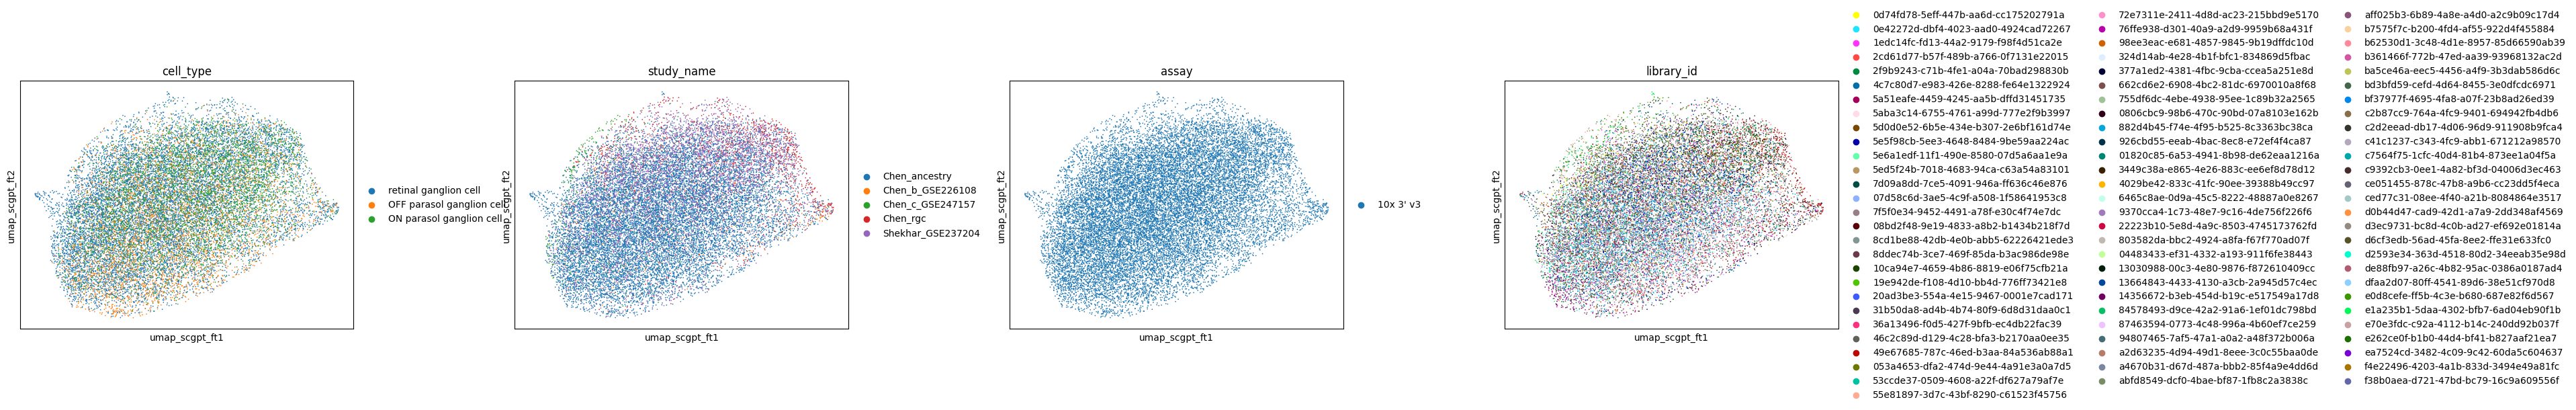

In [5]:
color_cols = [c for c in ["cell_type", "celltype", "cell_type_coarse", "batch", "dataset", "study_name", "assay", "library_id"] if c in adata.obs.columns]
print("Will color by:", color_cols)

sc.pl.embedding(adata, basis="umap_scgpt_ft", color=color_cols[:4], wspace=0.35)

In [6]:
adata.write_h5ad("retina_scgpt_cell_emb_finetuned_umap.h5ad")
print("saved: retina_scgpt_cell_emb_finetuned_umap.h5ad")



saved: retina_scgpt_cell_emb_finetuned_umap.h5ad


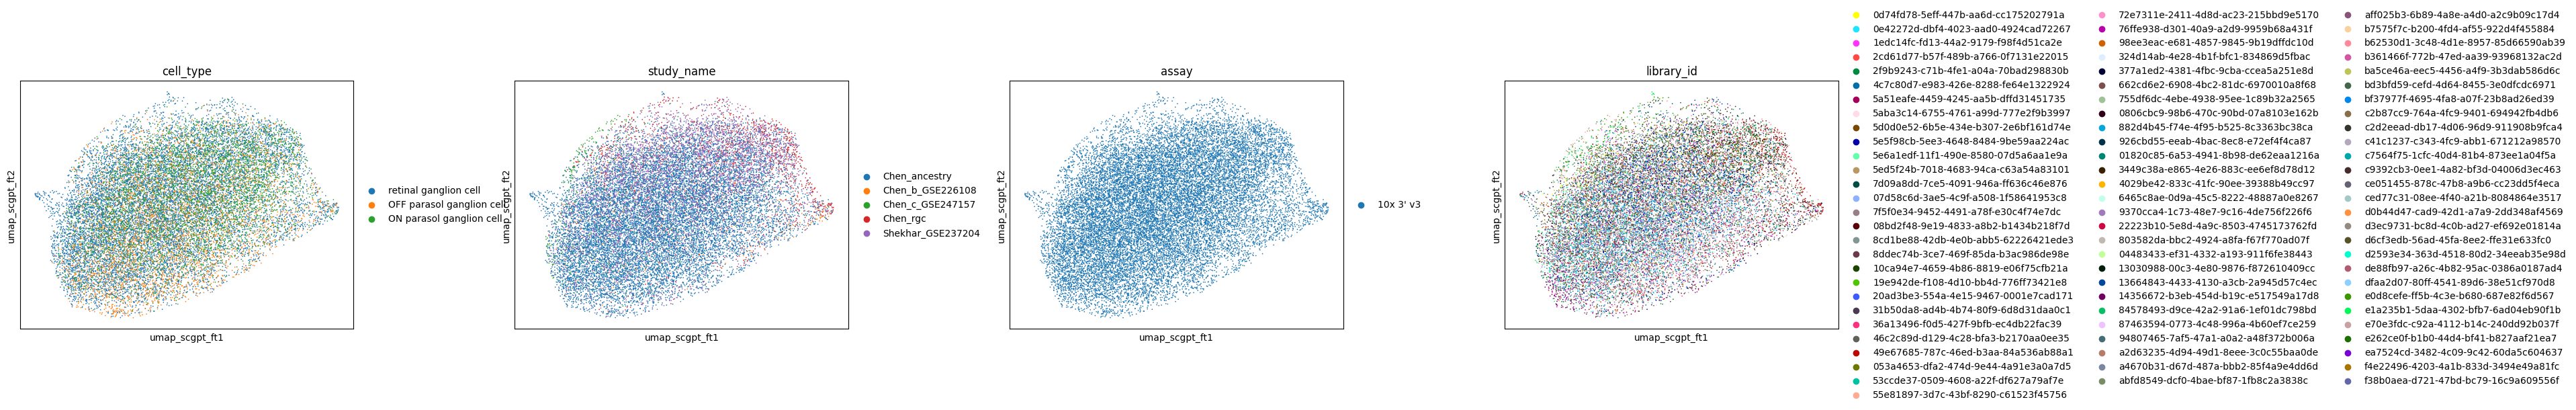

In [7]:
sc.pl.embedding(
    adata,
    basis="umap_scgpt_ft",
    color=color_cols[:4],
    wspace=0.35,
    save="_scgpt_finetuned.png"
)